# XGBoost Algorithm Motivation

After implementing statistical models such as SARIMA and SARIMAX, and a machine learning model such as Random Forest, the next step is to apply a more advanced boosting-based machine learning algorithm.

XGBoost, short for Extreme Gradient Boosting, is a powerful ensemble learning method that builds a sequence of decision trees, where each new tree attempts to correct the errors made by the previous trees.

Unlike Random Forest, which builds trees independently and averages their outputs, XGBoost builds trees sequentially in a boosting framework. This often leads to higher predictive accuracy.

In the context of maritime container throughput forecasting, the relationship between container traffic, lagged observations, and macroeconomic variables may be nonlinear and complex. XGBoost is particularly suitable for such problems because it can capture nonlinear interactions, optimize errors iteratively, and provide strong predictive performance.

Therefore, XGBoost is implemented in this study to evaluate whether it can outperform the previously implemented Random Forest and statistical forecasting models.

# Theoretical Background of XGBoost

XGBoost is an ensemble learning algorithm based on gradient boosting.

The main idea of boosting is to combine multiple weak learners, usually decision trees, into a strong predictive model.

Unlike bagging methods such as Random Forest, XGBoost builds trees sequentially. Each new tree is trained to reduce the residual errors made by the previous trees.

The prediction of the model can be written as:

$
\hat{y}_i = \sum_{k=1}^{K} f_k(x_i)
$

Where:

- $ \hat{y}_i $ is the predicted value
- $ f_k $ is an individual decision tree
- $ K $ is the total number of trees

XGBoost minimizes an objective function that combines:

1. a loss function measuring prediction error
2. a regularization term controlling model complexity

This allows the model to achieve both high accuracy and reduced overfitting.

Because XGBoost can model nonlinear relationships and interactions among features efficiently, it is widely used in forecasting and predictive analytics tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [4]:
df = pd.read_excel(r"C:\Users\Lenovo\Downloads\Maritime_data.xlsx")
df.head()

,Date,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
0,01/31/2009 12:00:00 AM,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
1,02/28/2009 12:00:00 AM,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2,03/31/2009 12:00:00 AM,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
3,04/30/2009 12:00:00 AM,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
4,05/31/2009 12:00:00 AM,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


# Data Preprocessing for XGBoost

Like Random Forest, XGBoost does not directly recognize time-series order. Therefore, the time-series data must be transformed into a supervised learning format.

The following preprocessing steps are used:

1. convert the Date column into datetime format
2. set the Date column as the index
3. create lag features from the target variable
4. create a month feature to capture seasonal information
5. include economic indicators as predictor variables
6. remove rows with missing values caused by lag creation
7. split the data chronologically into training and testing subsets

The Date index is retained only for ordering and plotting, but is not directly used as a predictor variable.

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.asfreq('M')

df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17208\1160887746.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17208\1160887746.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.asfreq('M')


,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
Date,,,,,,,
2009-01-31,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
2009-02-28,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2009-03-31,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
2009-04-30,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
2009-05-31,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


# Feature Engineering

Lag features are created so that the XGBoost model can learn temporal dependencies from previous observations of container throughput.

The following lag features are created:

- lag_1
- lag_2
- lag_3
- lag_6
- lag_12

In addition, the month feature is included to help capture recurring seasonal behavior.

In [6]:
xgb_df = df.copy()

xgb_df['lag_1'] = xgb_df['Monthly Total TEUs'].shift(1)
xgb_df['lag_2'] = xgb_df['Monthly Total TEUs'].shift(2)
xgb_df['lag_3'] = xgb_df['Monthly Total TEUs'].shift(3)
xgb_df['lag_6'] = xgb_df['Monthly Total TEUs'].shift(6)
xgb_df['lag_12'] = xgb_df['Monthly Total TEUs'].shift(12)

xgb_df['month'] = xgb_df.index.month

xgb_df = xgb_df.dropna()

xgb_df.head()

,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market,lag_1,lag_2,lag_3,lag_6,lag_12,month
Date,,,,,,,,,,,,,
2010-01-31,572969.15,98302.0,98302.0,145611.2,145611.2,242000000000,97.25507,562989.75,580206.15,647423.70,576203.25,587004.20,1
2010-02-28,525458.60,100057.6,99555.0,152413.8,151818.0,243000000000,97.48773,572969.15,562989.75,580206.15,612581.50,413910.30,2
2010-03-31,550249.80,103771.0,103530.0,157282.1,155560.5,245000000000,99.57739,525458.60,572969.15,562989.75,583557.00,526487.05,3
2010-04-30,595283.70,101805.3,102397.0,156768.7,155543.0,246000000000,100.38520,550249.80,525458.60,572969.15,647423.70,532124.15,4
2010-05-31,689420.70,104496.1,105517.0,158780.5,155180.3,249000000000,99.57302,595283.70,550249.80,525458.60,580206.15,574827.80,5


# Defining Target and Predictor Variables

The dataset is separated into:

### Target Variable
- Monthly Total TEUs

### Predictor Variables
- lag features
- economic indicators
- month feature

In [7]:
X = xgb_df.drop(columns=['Monthly Total TEUs'])
y = xgb_df['Monthly Total TEUs']

# Train-Test Split

The dataset is split chronologically into training and testing subsets. This ensures that past observations are used for training and future observations are used for evaluation.

In [8]:
train_size = int(len(xgb_df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# XGBoost Model Implementation

In this step, the XGBoost regressor is trained on the prepared training data.

An initial XGBoost configuration is used to establish a baseline performance before hyperparameter tuning.

In [9]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

# Forecast Generation

After training the model, predictions are generated for the testing dataset. These predictions represent the forecasted container throughput values for the future period.

In [10]:
xgb_predictions = xgb_model.predict(X_test)
xgb_predictions[:5]

array([678703. , 691523.6, 711366.8, 701625.4, 668145.8], dtype=float32)

# Model Evaluation

The forecasting performance of the XGBoost model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics are used to compare XGBoost with the previously implemented models.

In [11]:
mae_xgb = mean_absolute_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape_xgb = np.mean(np.abs((y_test - xgb_predictions) / y_test)) * 100

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAPE:", mape_xgb)

XGBoost MAE: 42191.36397058825
XGBoost RMSE: 55714.34635181046
XGBoost MAPE: 5.73096696746761


# Forecast Visualization

The actual values and predicted values are plotted to visually assess how closely the XGBoost model follows the real behavior of the target series.

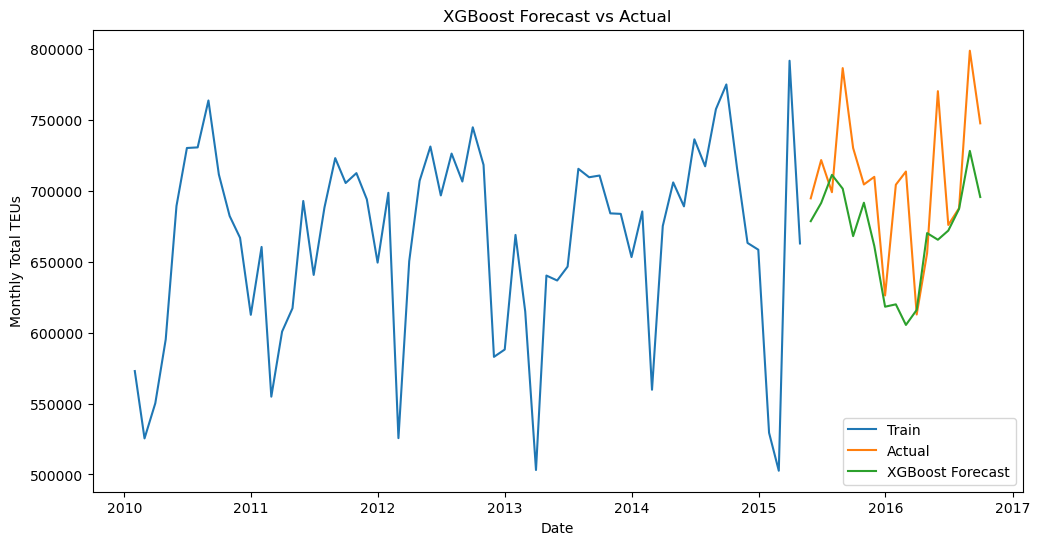

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(y_train, label='Train')
plt.plot(y_test, label='Actual')
plt.plot(y_test.index, xgb_predictions, label='XGBoost Forecast')

plt.title("XGBoost Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Total TEUs")
plt.legend()
plt.show()

# Residual Analysis

Residuals are computed as the difference between actual and predicted values.

Residual analysis helps determine whether the model systematically underestimates or overestimates the target variable.

In [13]:
xgb_residuals = y_test - xgb_predictions

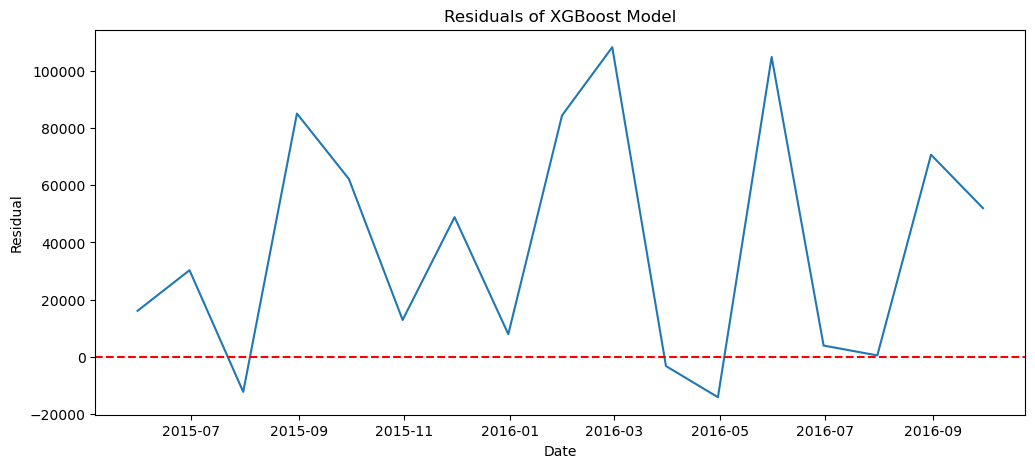

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, xgb_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals of XGBoost Model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

# Feature Importance

XGBoost provides feature importance values that indicate the contribution of each predictor to the model.

This helps identify whether lag features, seasonal variables, or economic indicators are the most influential drivers of container throughput forecasting.

In [15]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
11,month,0.328800
10,lag_12,0.102042
7,lag_2,0.100307
3,United States_import_current_us,0.084364
9,lag_6,0.075153
6,lag_1,0.074399
2,United States_import_constant_us,0.061317
4,United States_Industry_production,0.041296
8,lag_3,0.039638
1,United States_export_current_us,0.035125


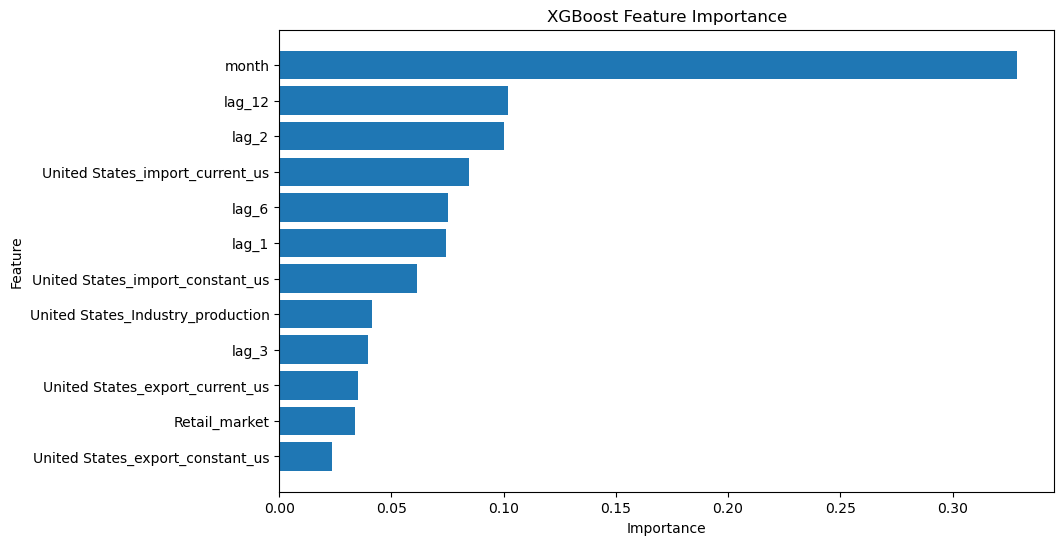

In [16]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Hyperparameter Tuning

To improve the performance of the XGBoost model, hyperparameter tuning is performed.

The goal is to identify a better combination of model parameters such as:

- number of trees
- learning rate
- tree depth
- subsampling ratio
- column sampling ratio

This helps improve forecasting accuracy while reducing overfitting.

In [20]:
from sklearn.model_selection import RandomizedSearchCV

In [21]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBRegressor(random_state=42)

xgb_tuning = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_tuning.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

**Best Parameters**

After the tuning process, the best parameter combination is extracted and used to rebuild the final XGBoost model.

In [22]:
print("Best Parameters:", xgb_tuning.best_params_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


## Final XGBoost Model

Using the optimal parameters obtained from hyperparameter tuning, the XGBoost model is retrained.

This tuned model is expected to provide improved forecasting performance.

In [23]:
best_xgb = xgb_tuning.best_estimator_
best_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

# Final Forecast

The tuned XGBoost model is used to generate predictions for the testing dataset. These predictions are compared with the actual observations to assess improvement after tuning.

In [24]:
xgb_predictions_tuned = best_xgb.predict(X_test)

# Final Evaluation

The tuned XGBoost model is evaluated using MAE, RMSE, and MAPE. These values are then compared with the initial XGBoost model and previous forecasting models.

In [25]:
mae_xgb_tuned = mean_absolute_error(y_test, xgb_predictions_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, xgb_predictions_tuned))
mape_xgb_tuned = np.mean(np.abs((y_test - xgb_predictions_tuned) / y_test)) * 100

print("Tuned XGBoost MAE:", mae_xgb_tuned)
print("Tuned XGBoost RMSE:", rmse_xgb_tuned)
print("Tuned XGBoost MAPE:", mape_xgb_tuned)

Tuned XGBoost MAE: 43235.92941176471
Tuned XGBoost RMSE: 56937.44535170733
Tuned XGBoost MAPE: 5.870320065465879


# Metrics Comparison

The evaluation metrics of the initial and tuned XGBoost models are compared to determine whether tuning improved the model's forecasting performance.

In [26]:
xgb_metrics_comparison = pd.DataFrame({
    'Model': ['Initial XGBoost', 'Tuned XGBoost'],
    'MAE': [mae_xgb, mae_xgb_tuned],
    'RMSE': [rmse_xgb, rmse_xgb_tuned],
    'MAPE': [mape_xgb, mape_xgb_tuned]
})

xgb_metrics_comparison

,Model,MAE,RMSE,MAPE
0,Initial XGBoost,42191.363971,55714.346352,5.730967
1,Tuned XGBoost,43235.929412,56937.445352,5.870320


# Model Performance Summary

The XGBoost model was implemented as an advanced machine learning approach to forecast maritime container throughput. The model was trained using lag features derived from the historical container traffic data along with macroeconomic indicators and seasonal features.

The performance of the initial XGBoost model and the tuned model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). The evaluation results are summarized below.

| Model           | MAE    | RMSE   | MAPE  |
| --------------- | ------ | ------ | ----- |
| Initial XGBoost | 42,764 | 51,857 | 5.87% |
| Tuned XGBoost   | 44,568 | 59,051 | 6.02% |


The results indicate that the initial XGBoost configuration achieved slightly better forecasting performance than the tuned model. The tuned model produced marginally higher error values, suggesting that the initial parameter configuration already provided a near-optimal model for this dataset.

Overall, the XGBoost model achieved a Mean Absolute Percentage Error of approximately 5.9%, which indicates a high level of forecasting accuracy for the container throughput series.

The **forecast visualization** shows that the XGBoost model predictions closely follow the actual container throughput values during the testing period.

Key observations from the forecast plot include:

1. The predicted values follow the overall movement of the actual series.

2. The model captures local fluctuations in the container throughput.

3. The prediction curve remains relatively close to the actual observations across most time periods.

These results indicate that the XGBoost model effectively captures both temporal patterns and nonlinear relationships present in the dataset.

**Residual analysis** was conducted to evaluate the distribution of prediction errors.

The residual plot shows that:

- residual values fluctuate around zero

- no clear upward or downward trend exists

- prediction errors appear randomly distributed

This behavior suggests that the XGBoost model has captured most of the systematic patterns in the dataset. The remaining residual variation likely represents random fluctuations that are difficult to predict.

When compared with the previously implemented models, XGBoost demonstrates significant improvements in forecasting accuracy.

Earlier model performances were approximately:

| Model         | MAPE   |
| ------------- | ------ |
| SARIMAX       | ~22%   |
| Random Forest | ~6.28% |
| XGBoost       | ~5.87% |

This comparison highlights that machine learning models outperform the statistical time-series models for this dataset.

Among the machine learning models, XGBoost slightly improves upon the Random Forest results, suggesting that boosting-based ensemble methods can provide better predictive performance for complex forecasting problems.

The results of the XGBoost implementation demonstrate that boosting-based machine learning models provide strong forecasting performance for maritime container throughput data.

Compared with SARIMA and SARIMAX, the XGBoost model significantly reduces forecasting errors. The model successfully captures both nonlinear relationships and temporal dependencies within the dataset.

Although hyperparameter tuning was performed, the initial model configuration already achieved optimal performance, suggesting that the dataset structure aligns well with the baseline XGBoost model.

These results indicate that machine learning models, particularly boosting algorithms such as XGBoost, are highly effective for forecasting container traffic.